# Overview - Welcome to week 6 practical (coding part)


In this week, we move from exploring data to building our first simple predictive model.

You will learn how to:

* Split data into training and testing sets

* Build a linear regression model to predict numerical values

* Understand how predictions are made

* Measure and interpret prediction errors

* (Optional) Visualise how well the model performs

By the end of this practical, you will understand how data can be used to make predictions, and how to evaluate whether those predictions are reasonable.

## 🐍 Python Libraries We'll Use

- **[pandas](https://pypi.org/project/pandas/)** - a Python package that provides fast, flexible, and expressive data structures designed to make working with "relational" or "labeled" data both easy and intuitive.

- **[NumPy](https://pypi.org/project/numpy/)** - The fundamental package for scientific computing with Python.

- **[Matplotlib](https://matplotlib.org/stable/index.html)** - Matplotlib is a low level graph plotting library in python that serves as a visualization utility.

- **[scikit-learn](https://scikit-learn.org/stable/)** - scikit-learn (formerly scikits.learn and also known as sklearn) is a free and open-source machine learning library for the Python programming language.

In [ ]:
# Please import before using.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 📊 Dataset We'll Use

In this practical, we will use the Diabetes dataset from scikit-learn.

This dataset contains medical information about patients, such as:

* body mass index (BMI)

* blood pressure

* age

* various blood serum measurements

The goal is to predict *a quantitative measure of disease progression one year after baseline*.

This is **a regression problem**, where we aim to predict a numerical value.

In [ ]:
# Load and Inspect the Data
# Load the dataset as a pandas DataFrame
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# Display the first few rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


🔍 **Check basic information**

In [ ]:
# Practiced in last week
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


# Separate Features and Target

To build a predictive model, we need to separate the dataset into:

* **features (X)**: the input variables used for prediction

* **target (y)**: the value we want to predict

In this notebook, we will use all features to predict disease progression.

In [ ]:
# X contains all input features except the target column
X = df.drop(columns=["target"])

# y contains the target variable
y = df["target"]

# Display the first few rows of X
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
# Display the first few target values
y.head()

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


# Train–Test Split

A model should not be evaluated on the same data it learned from.

To make evaluation more meaningful, we split the dataset into:

* a **training** set, used to train the model

* a **testing** set, used to evaluate how well the model performs on unseen data

In [ ]:
# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state=42 ensures the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)


**Explanation**

This is one of the most important steps in machine learning.

If we train and test on exactly the same data, the results can be misleading.
By holding back some data for testing, we get a better idea of how the model might perform on new examples.

The argument random_state=42 is included so that everyone gets the same split each time they run the code. This is useful in teaching and debugging.

# Build and Train a Linear Regression Model

Now we create a **linear regression model** and fit it to the training data.

Linear regression tries to model the relationship between the input features and the target variable using a linear equation.

In [ ]:
# Create the linear regression model
model = LinearRegression()

# Train (fit) the model using the training data
model.fit(X_train, y_train)

LinearRegression()

**Explanation**

* *LinearRegression()* creates the model

* *model.fit(X_train, y_train)* trains the model using the training data

Because we are using multiple features, the model learns one coefficient for each feature, plus an intercept.

# Inspect the Model

After training, we can inspect some of the model output.

In particular, we can look at:

* the **intercept**

* the **coefficients** for each feature

In [ ]:
# Print the intercept
print("Intercept:", model.intercept_)

Intercept: 151.34560453985995


In [ ]:
# Put feature coefficients into a DataFrame for easier reading
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,age,37.904021
1,sex,-241.964362
2,bmi,542.428759
3,bp,347.703844
4,s1,-931.488846
5,s2,518.062277
6,s3,163.419983
7,s4,275.317902
8,s5,736.198859
9,s6,48.670657


## 🧑‍🎓 Your turn ...

🤔️ Can you write down the learned linear model?

In [ ]:
# Your answer here

**Explanation**

The *intercept* is the baseline prediction when all feature values are zero.

Each *coefficient* shows the relationship between one feature and the target, while holding the other features constant.

A:

* **positive coefficient** suggests the target tends to increase as that feature increases

* **negative coefficient** suggests the target tends to decrease as that feature increases

At this stage, we are only making a basic interpretation. We are not trying to make strong scientific conclusions from the coefficients.

# Make Predictions

Now that the model has been trained, we can use it to make predictions on the **test set**.

In [ ]:
# Generate predictions for the test set
y_pred = model.predict(X_test)

# Create a DataFrame to compare actual and predicted values
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

# Show the first few rows
results_df.head(10)

,Actual,Predicted
287,219.0,139.547558
211,70.0,179.517208
72,202.0,134.038756
321,230.0,291.417029
73,111.0,123.789659
418,84.0,92.172347
367,242.0,258.232389
354,272.0,181.337321
281,94.0,90.224113
148,96.0,108.633759


**Explanation**

The method *model.predict(X_test)* uses the trained model to generate predicted target values.

Creating a comparison table helps us see how close the predicted values are to the actual values.

# Understand Prediction Errors

Predictions are usually not perfect, so we need a way to measure error.

We will use two common regression metrics:

* ***Mean Absolute Error (MAE)***
This measures the average absolute difference between actual and predicted values.

* ***Mean Squared Error (MSE)***
This measures the average squared difference between actual and predicted values. Larger errors are penalised more heavily.

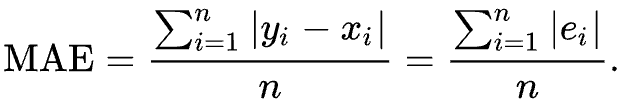

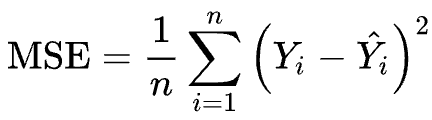

In [ ]:
# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)

Mean Absolute Error (MAE): 42.79409467959994
Mean Squared Error (MSE): 2900.1936284934814


**Explanation**

These metrics help us judge how far the predictions are from the actual values.

In general:

* *lower error values* indicate better predictions

* *higher error values* indicate worse predictions

However, error values should always be interpreted in context. A number is only meaningful when you know what the target variable represents and what range of values is typical.

## 🧑‍🎓 Your turn ...

**Check the Absolute Error**

Create a new column called Absolute Error that shows the absolute difference between actual and predicted values.

Then display the first 10 rows.

In [ ]:
# Your answer here

# Optional Visual Check: Predicted vs Actual

A simple scatter plot can help us visually compare predicted values and actual values.

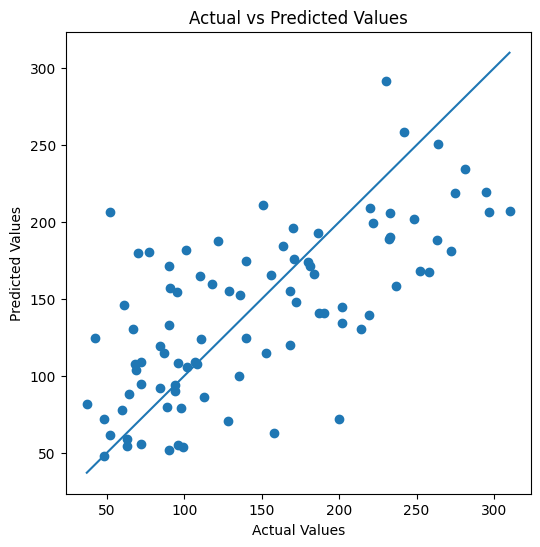

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

# Add a reference line where predicted = actual
# This helps us see how close the points are to perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

**Explanation**

In this plot:

* each point represents one test example

* the x-axis shows the actual value

* the y-axis shows the predicted value

If predictions were perfect, all points would lie exactly on the diagonal reference line.

The closer the points are to that line, the better the predictions match the true values.

# Summary

At this point, we have completed a simple modelling workflow:

* loaded the data

* separated features and target

* split data into training and testing sets

* trained a linear regression model

* made predictions

* evaluated prediction errors

* visually checked the results

Some important things to remember:

1. The model can find patterns in the data, but predictions are not perfect

2. Error metrics help us quantify model performance

3. Coefficients can provide some insight into feature relationships

4. A reasonable model is useful even if it is not perfect

In this practical, the goal is to understand the workflow and interpret the output, rather than trying to improve the model with more advanced techniques.